In [1]:
from pynhd import NLDI, WaterData, NHDPlusHR, GeoConnex
import geopandas as gpd
import pandas as pd
from supporting_scripts import getData, SNOTEL_Analyzer, dataprocessing, mapping
from shapely.geometry import box, Polygon
import os
import datetime
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [ ]:
#NWIS for a station with a high elevation SNOTEL
nldi = NLDI()
usgs_gage_id = "10105900" # NWIS id for Little Bear RIver
WY = 2026 # Water Year to analyze, from activity it says 2026.

In [ ]:
nldi = NLDI()

#Getting basin geometry
print('Collecting basins...', end='')
basin = nldi.get_basins(usgs_gage_id)
if not os.path.exists('files'):
    os.makedirs('files')
basin.to_file("files/LittleBearRiverBasin.shp")
print('done')

site_feature = nldi.getfeature_byid("nwissite", f"USGS-{usgs_gage_id}")
upstream_network = nldi.navigate_byid(
    "nwissite", f"USGS-{usgs_gage_id}", "upstreamMain", "flowlines", distance=9999
)

In [4]:
mapping.basin_mapping(basin, site_feature)

In [5]:
# Create geodataframe of all stations
all_stations_gdf = gpd.read_file('https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson').set_index('code')
all_stations_gdf = all_stations_gdf[all_stations_gdf['csvData']==True]

# Use the polygon geometry to select snotel sites that are within the domain
gdf_in_bbox = all_stations_gdf[all_stations_gdf.geometry.within(basin.geometry[0])]

#reset index to have siteid as a column
gdf_in_bbox.reset_index(drop=False, inplace=True)

#make begin and end date a str
gdf_in_bbox['beginDate'] = [datetime.datetime.strftime(gdf_in_bbox['beginDate'][i], "%Y-%m-%d") for i in np.arange(0,len(gdf_in_bbox),1)]
gdf_in_bbox['endDate'] = [datetime.datetime.strftime(gdf_in_bbox['endDate'][i], "%Y-%m-%d") for i in np.arange(0,len(gdf_in_bbox),1)]
gdf_in_bbox

,code,name,network,elevation_m,latitude,longitude,state,HUC,mgrs,mountainRange,beginDate,endDate,csvData,geometry
0,455_UT_SNTL,Dry Bread Pond,SNOTEL,2530.449707,41.412891,-111.537697,Utah,160102030101,12TVL,Western Rocky Mountains,1978-10-01,2026-03-05,True,POINT (-111.5377 41.41289)
1,582_UT_SNTL,Little Bear,SNOTEL,1995.830444,41.405621,-111.826073,Utah,160102030103,12TVL,Western Rocky Mountains,1978-10-01,2026-03-05,True,POINT (-111.82607 41.40562)


In [6]:
mapping.snotel_mapping(gdf_in_bbox, basin, site_feature)

In [9]:
state_abbr_map = {
   'Utah': 'UT',
}

OutputFolder = 'files/SNOTEL'
if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)

gdf_in_bbox = gdf_in_bbox.reset_index(drop=True)

for i in gdf_in_bbox.index:
    state_raw = gdf_in_bbox.state[i]
    # Handle both full names and already-abbreviated states
    state_abbr = state_abbr_map.get(state_raw, state_raw)
    getData.getSNOTELData(gdf_in_bbox.name[i], gdf_in_bbox.code[i], state_abbr,
                          gdf_in_bbox.beginDate[i], gdf_in_bbox.endDate[i], OutputFolder)

Start retrieving data for Dry Bread Pond, 455_UT_SNTL 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/455:UT:SNTL%7Cid=%22%22%7Cname/1978-10-01,2026-03-05/WTEQ::value?fitToScreen=false
Start retrieving data for Little Bear, 582_UT_SNTL 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/582:UT:SNTL%7Cid=%22%22%7Cname/1978-10-01,2026-03-05/WTEQ::value?fitToScreen=false


In [10]:
import importlib.util
importlib.reload(dataprocessing)

<module 'supporting_scripts.dataprocessing' from '/uufs/chpc.utah.edu/common/home/u1566670/hydroinformatics/Data-Acquisition-Processing-Analysis/supporting_scripts/dataprocessing.py'>

In [14]:

# Load the data for one site
sites = list(gdf_in_bbox.code)
stateab = 'UT'
sitedict = dict()

for site in sites:
    sitedict[site] = dataprocessing.processSNOTEL(site, stateab, WY)



455_UT_SNTL
Dropping 2026 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
582_UT_SNTL
Dropping 2026 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site


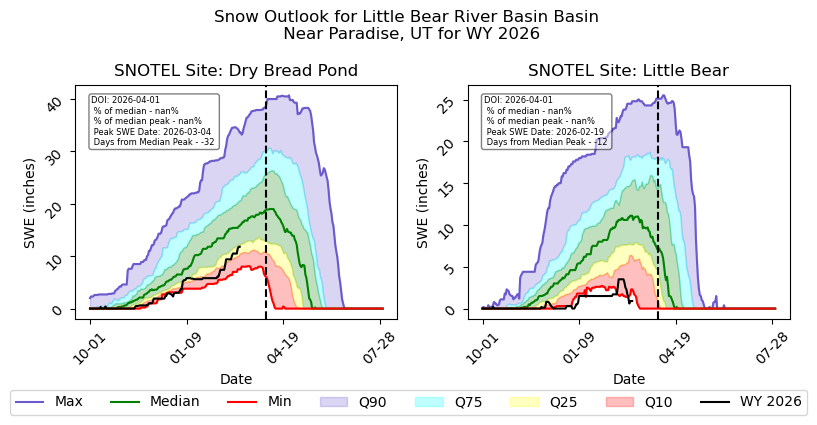

In [16]:
watershed = "Little Bear River Basin"
AOI = 'Near Paradise, UT'
DOI = '04-01' #must be in MM-DD form
SNOTEL_Analyzer.SNOTELPlots(sitedict, gdf_in_bbox, WY, watershed, AOI,DOI)

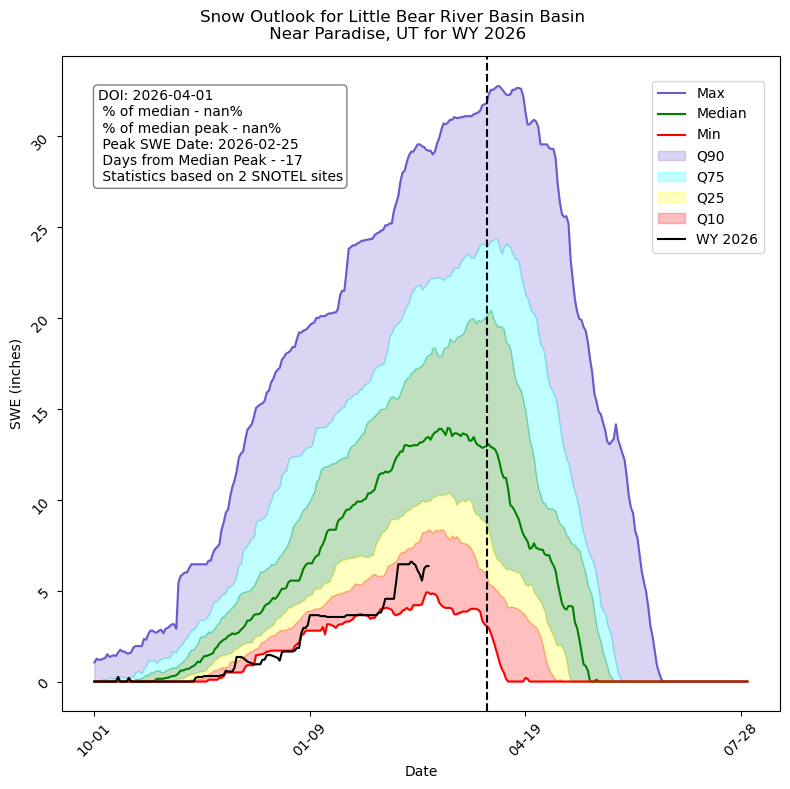

In [17]:
watershed = "Little Bear River Basin"
AOI = 'Near Paradise, UT'
DOI = '04-01' #must be in MM-DD form

SNOTEL_Analyzer.catchmentSNOTELAnalysis(sitedict, WY, watershed, AOI, DOI)